# Odisha Rice Yield — Machine Learning Notebook

This notebook builds on the completed EDA (`Odisha_Rice_Complete_Combined_EDA_Final.ipynb`) and the cleaned dataset it produced (`odisha_rice_integrated_eda_clean.csv`).

**Audited methodology:** the project uses a chronological holdout (2014–2021 train, 2022–2024 final test). Within the training period, validation is also **year-aware**: whole years are kept together so a validation year never shares rows with the training fold. The final test set is used only once, after model/hyperparameter selection, to estimate future-year performance.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1. Load the cleaned CSV and inspect it

In [20]:
df = pd.read_csv("odisha_rice_integrated_eda_clean.csv")

print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (839, 18)


,fiscal_year,district,district_source,district_lgd_code,season,area,production,reported_crop_yield,year,avg_temperature_c,rainfall_mm,humidity_pct,soil_ph,nitrogen_kg_ha,phosphorus_kg_ha,potassium_kg_ha,irrigation_pct,yield_kg_ha
0,2024-25,Sambalpur,Sambalpur,371.0,Summer,16603.88,69639.30,4194.0,2024,29.6,1187.0,85.3,5.43,303.0,29.0,177.0,62.0,4194.158233
1,2024-25,Sonepur,Sonepur,372.0,Summer,40999.70,156856.79,3826.0,2024,27.6,1327.0,80.9,5.29,289.0,23.0,176.0,32.0,3825.803360
2,2024-25,Jharsuguda,Jharsuguda,357.0,Summer,1951.99,7162.65,3669.0,2024,28.5,1516.0,87.7,5.56,271.0,23.0,177.0,45.0,3669.409167
3,2024-25,Bargarh,Bargarh,347.0,Summer,100936.27,367524.57,3641.0,2024,30.4,1484.0,87.8,6.18,262.0,23.0,187.0,69.0,3641.154661
4,2024-25,Khordha,Khordha,362.0,Summer,1752.99,6083.98,3471.0,2024,29.8,1297.0,80.3,6.14,279.0,27.0,158.0,44.0,3470.630180


In [21]:
print("Column names:")
for col in df.columns:
    print(f"  - {col}")

Column names:
  - fiscal_year
  - district
  - district_source
  - district_lgd_code
  - season
  - area
  - production
  - reported_crop_yield
  - year
  - avg_temperature_c
  - rainfall_mm
  - humidity_pct
  - soil_ph
  - nitrogen_kg_ha
  - phosphorus_kg_ha
  - potassium_kg_ha
  - irrigation_pct
  - yield_kg_ha


In [22]:
df.dtypes

fiscal_year                str
district                   str
district_source            str
district_lgd_code      float64
season                     str
area                   float64
production             float64
reported_crop_yield    float64
year                     int64
avg_temperature_c      float64
rainfall_mm            float64
humidity_pct           float64
soil_ph                float64
nitrogen_kg_ha         float64
phosphorus_kg_ha       float64
potassium_kg_ha        float64
irrigation_pct         float64
yield_kg_ha            float64
dtype: object

In [23]:
missing = df.isnull().sum()
missing = missing[missing > 0]

if missing.empty:
    print("No missing values in any column.")
else:
    print("Columns with missing values:")
    print(missing)

No missing values in any column.


In [24]:
n_duplicates = df.duplicated().sum()
print(f"Number of fully duplicated rows: {n_duplicates}")

Number of fully duplicated rows: 0


In [25]:
available_years = sorted(df["year"].unique())
print("Available years:", available_years)
print("Number of distinct years:", len(available_years))

Available years: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Number of distinct years: 11


## 2. Define the target

The task specifies a target column named `yield`. That exact column name is
**not** present in this dataset — verified below.

Instead, the cleaned dataset (per the EDA, Section "18. ML-ready feature
definition") provides a purpose-built, unit-consistent target column:

```
yield_kg_ha = production (tonnes) * 1000 / area (ha)
```

This was engineered during the EDA specifically because the raw
`reported_crop_yield` column mixes units across years and is unreliable
(the EDA shows it correlates only weakly with the recomputed yield). We use
`yield_kg_ha` as the modeling target and treat it as the `yield` referred to
in the task instructions.

In [26]:
assert "yield" not in df.columns, "Unexpected: a literal 'yield' column exists."
assert "yield_kg_ha" in df.columns, "Expected target column 'yield_kg_ha' is missing."

print("'yield' column present:", "yield" in df.columns)
print("'yield_kg_ha' column present:", "yield_kg_ha" in df.columns)

TARGET = "yield_kg_ha"
y = df[TARGET]

y.describe()

'yield' column present: False
'yield_kg_ha' column present: True


count     839.000000
mean     2255.246201
std       852.921448
min         0.000000
25%      1662.195220
50%      2234.021070
75%      2825.709914
max      4838.996321
Name: yield_kg_ha, dtype: float64

## 3. Define features

`production` is explicitly excluded from the feature matrix because it is
directly tied to the target through area:

```
production ≈ area * yield_kg_ha / 1000
```

Including it would leak the target into the predictors.

Beyond `production` and the target itself, the remaining columns are
inspected individually for identifiers, target-derived fields, and other
non-predictive variables before building `X`.

In [27]:
for col in df.columns:
    print(f"{col:22s} | dtype={str(df[col].dtype):8s} | n_unique={df[col].nunique()}")

fiscal_year            | dtype=str      | n_unique=11
district               | dtype=str      | n_unique=30
district_source        | dtype=str      | n_unique=34
district_lgd_code      | dtype=float64  | n_unique=30
season                 | dtype=str      | n_unique=4
area                   | dtype=float64  | n_unique=701
production             | dtype=float64  | n_unique=741
reported_crop_yield    | dtype=float64  | n_unique=685
year                   | dtype=int64    | n_unique=11
avg_temperature_c      | dtype=float64  | n_unique=80
rainfall_mm            | dtype=float64  | n_unique=488
humidity_pct           | dtype=float64  | n_unique=168
soil_ph                | dtype=float64  | n_unique=177
nitrogen_kg_ha         | dtype=float64  | n_unique=160
phosphorus_kg_ha       | dtype=float64  | n_unique=28
potassium_kg_ha        | dtype=float64  | n_unique=102
irrigation_pct         | dtype=float64  | n_unique=75
yield_kg_ha            | dtype=float64  | n_unique=770


In [28]:
# Columns to exclude from the feature matrix, with justification:
#
#   yield_kg_ha         -> the target itself
#   production          -> target leakage: production ~= area * yield_kg_ha / 1000
#   reported_crop_yield -> a second, unit-inconsistent yield figure derived from
#                          the same production/area relationship; using it as a
#                          predictor would also leak the target
#   district_lgd_code   -> a government identifier code, not a continuous
#                          measurement; district identity is already captured
#                          by the categorical 'district' column
#   district_source     -> a raw district-name variant kept only for merge
#                          traceability during the EDA, redundant with 'district'
#   fiscal_year         -> a string-formatted duplicate of 'year' (e.g. "2021-22"),
#                          redundant with the numeric 'year' column

leakage_or_id_columns = [
    "yield_kg_ha",
    "production",
    "reported_crop_yield",
    "district_lgd_code",
    "district_source",
    "fiscal_year",
]

missing_cols = [c for c in leakage_or_id_columns if c not in df.columns]
assert not missing_cols, f"Expected columns not found in df: {missing_cols}"

X = df.drop(columns=leakage_or_id_columns)

print("Excluded columns:", leakage_or_id_columns)
print("\nRemaining feature columns:")
for col in X.columns:
    print(f"  - {col}")
print(f"\nX shape: {X.shape}")

Excluded columns: ['yield_kg_ha', 'production', 'reported_crop_yield', 'district_lgd_code', 'district_source', 'fiscal_year']

Remaining feature columns:
  - district
  - season
  - area
  - year
  - avg_temperature_c
  - rainfall_mm
  - humidity_pct
  - soil_ph
  - nitrogen_kg_ha
  - phosphorus_kg_ha
  - potassium_kg_ha
  - irrigation_pct

X shape: (839, 12)


## 4. Identify feature types

Numerical and categorical columns are taken from the actual columns
remaining in `X` (not assumed).

In [29]:
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_features = X.select_dtypes(include=["number"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

assert set(categorical_features) | set(numerical_features) == set(X.columns), \
    "Some columns in X were not classified as numerical or categorical."
assert not (set(categorical_features) & set(numerical_features)), \
    "A column was classified as both numerical and categorical."

print("\nAll columns in X accounted for:", 
      set(categorical_features) | set(numerical_features) == set(X.columns))

Categorical features: ['district', 'season']
Numerical features: ['area', 'year', 'avg_temperature_c', 'rainfall_mm', 'humidity_pct', 'soil_ph', 'nitrogen_kg_ha', 'phosphorus_kg_ha', 'potassium_kg_ha', 'irrigation_pct']

All columns in X accounted for: True


In [30]:
for col in categorical_features:
    print(f"{col}: {sorted(X[col].unique())}")

district: ['Anugul', 'Balangir', 'Balasore', 'Bargarh', 'Bhadrak', 'Boudh', 'Cuttack', 'Deogarh', 'Dhenkanal', 'Gajapati', 'Ganjam', 'Jagatsinghapur', 'Jajapur', 'Jharsuguda', 'Kalahandi', 'Kandhamal', 'Kendrapara', 'Kendujhar', 'Khordha', 'Koraput', 'Malkangiri', 'Mayurbhanj', 'Nabarangpur', 'Nayagarh', 'Nuapada', 'Puri', 'Rayagada', 'Sambalpur', 'Sonepur', 'Sundargarh']
season: ['Autumn', 'Kharif', 'Summer', 'Winter']


## 5. Analyze the year distribution

The year distribution determines where a chronological split can sensibly
be drawn.

In [31]:
year_counts = df["year"].value_counts().sort_index()
print(year_counts)

print(f"\nMinimum year: {df['year'].min()}")
print(f"Maximum year: {df['year'].max()}")

year
2014    79
2015    76
2016    87
2017    86
2018    82
2019    83
2020    86
2021    86
2022    84
2023    30
2024    60
Name: count, dtype: int64

Minimum year: 2014
Maximum year: 2024


## 6. Create a chronological train-test split

A random split (e.g. `train_test_split(..., random_state=42)`) would mix
observations from the same year across both the training and test sets.
Since weather, soil, and input conditions are shared within a year across
districts, a random split lets the model implicitly "see" test-year
conditions during training via other rows from the same year — inflating
apparent performance. Real-world use of this model means predicting yield
for **years that haven't happened yet**, so evaluation must mimic that:
train on earlier years, test on strictly later years.

**Choosing the cutoff:** the dataset spans 2014–2024 (11 years, 839 rows).
Holding out the most recent three years (2022–2024) as the test set gives:

- Training years: 2014–2021 (8 years)
- Testing years: 2022–2024 (3 years, including the partially-observed 2023
  and 2024 fiscal years already visible in the year distribution above)

This keeps every test-year observation strictly after every training-year
observation, and gives a test set that is a meaningful but not excessive
share of the data.

In [32]:
CUTOFF_YEAR = 2021

train_df = df[df["year"] <= CUTOFF_YEAR].copy()
test_df = df[df["year"] > CUTOFF_YEAR].copy()

train_years = sorted(train_df["year"].unique())
test_years = sorted(test_df["year"].unique())

assert max(train_years) < min(test_years), \
    "Chronological split violated: some training years overlap with or exceed test years."

print(f"Cutoff year: {CUTOFF_YEAR}  (train: year <= {CUTOFF_YEAR}, test: year > {CUTOFF_YEAR})")
print("Training years:", train_years)
print("Testing years:", test_years)

Cutoff year: 2021  (train: year <= 2021, test: year > 2021)
Training years: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]
Testing years: [np.int64(2022), np.int64(2023), np.int64(2024)]


## 7. Separate X_train, X_test, y_train, y_test

The same set of excluded columns from Section 3 is dropped from both the
training and test partitions.

In [33]:
X_train = train_df.drop(columns=leakage_or_id_columns)
y_train = train_df[TARGET]

X_test = test_df.drop(columns=leakage_or_id_columns)
y_test = test_df[TARGET]

assert list(X_train.columns) == list(X.columns), "X_train columns do not match X."
assert list(X_test.columns) == list(X.columns), "X_test columns do not match X."

## 8. Split summary

In [34]:
print("=" * 50)
print("CHRONOLOGICAL TRAIN-TEST SPLIT SUMMARY")
print("=" * 50)
print(f"Training years           : {train_years[0]}-{train_years[-1]}")
print(f"Testing years            : {test_years[0]}-{test_years[-1]}")
print(f"Number of training rows  : {len(train_df)}")
print(f"Number of testing rows   : {len(test_df)}")
print(f"Train/test split         : {len(train_df)/len(df):.1%} / {len(test_df)/len(df):.1%}")
print(f"X_train shape            : {X_train.shape}")
print(f"X_test shape             : {X_test.shape}")
print(f"y_train shape            : {y_train.shape}")
print(f"y_test shape             : {y_test.shape}")
print("=" * 50)

CHRONOLOGICAL TRAIN-TEST SPLIT SUMMARY
Training years           : 2014-2021
Testing years            : 2022-2024
Number of training rows  : 665
Number of testing rows   : 174
Train/test split         : 79.3% / 20.7%
X_train shape            : (665, 12)
X_test shape             : (174, 12)
y_train shape            : (665,)
y_test shape             : (174,)


## 9. Notes

**Why this is a regression problem**
The target, `yield_kg_ha`, is a continuous numeric quantity (kilograms of
rice per hectare). Predicting a continuous value — rather than a class
label — makes this a regression task.

**Why `production` (and `reported_crop_yield`) are excluded**
`production` is related to the target by definition:
`production ≈ area × yield_kg_ha / 1000`. If `production` were included as a
predictor, the model could reconstruct the target almost exactly from
`production` and `area` alone, without learning anything about the
agronomic drivers of yield (weather, soil, nutrients, irrigation). This is
target leakage, and it would make the model look far more accurate than it
could ever be in a real forecasting setting, where `production` for a
future season is not known in advance — it's the thing the yield feeds into
computing, not a predictor of it. `reported_crop_yield` is excluded for the
same underlying reason: it is another figure derived from the same
production/area relationship, and it also has an unresolved unit
inconsistency across years (per the EDA).

**Why a chronological split is preferred over a random split**
Agricultural conditions (weather, rainfall, soil nutrients) are strongly
correlated *within* a year across districts. A random split can place two
rows from the same year — one in training, one in testing — which lets the
model implicitly learn about test-year conditions through the training
rows from that same year. This overstates how well the model would perform
on truly unseen future years.

**Why future years must not appear in training**
The model's real-world purpose is to predict yield for seasons that have
not happened yet, using only information available up to the present. If
future-year data leaked into training, the evaluation would no longer
reflect that real deployment scenario, and reported performance would be
optimistic in a way that would not hold up in practice.

## 10. Verify the existing train/test split

Before building preprocessing, we re-confirm that `X_train`, `X_test`,
`y_train`, and `y_test` still reflect the chronological split created in
Section 7 — not a random split — and that the test set is entirely from
years after the training set.

In [35]:
assert "X_train" in dir() and "X_test" in dir() and "y_train" in dir() and "y_test" in dir(), \
    "X_train/X_test/y_train/y_test must already exist from the earlier split section."

train_years_check = sorted(train_df["year"].unique())
test_years_check = sorted(test_df["year"].unique())

assert max(train_years_check) < min(test_years_check), \
    "Split is not chronological: training years overlap with or exceed testing years."
assert len(X_train) == len(y_train) and len(X_test) == len(y_test), \
    "X/y length mismatch within a split."
assert list(X_train.columns) == list(X_test.columns), \
    "X_train and X_test do not have matching columns."

print("Existing chronological split verified (unchanged).")
print(f"Train years {train_years_check[0]}-{train_years_check[-1]}  ({len(X_train)} rows)")
print(f"Test years  {test_years_check[0]}-{test_years_check[-1]}  ({len(X_test)} rows)")

Existing chronological split verified (unchanged).
Train years 2014-2021  (665 rows)
Test years  2022-2024  (174 rows)


## 11. Preprocessing

**Why preprocessing is required**
The raw features mix very different scales (e.g. `area` in the tens of
thousands vs. `soil_ph` around 5-7) and data types (numeric measurements vs.
text categories like `district` and `season`). Most ML algorithms either
assume numeric input only, or are sensitive to feature scale, so the raw
`X_train`/`X_test` frames can't be fed to a model as-is.

**Why categorical variables need encoding**
`district` and `season` are text labels with no inherent numeric order.
Models require numeric input, and encoding them as arbitrary integers would
falsely imply an ordering (e.g. that one district is "greater than"
another). One-hot encoding avoids this by representing each category as its
own binary indicator column, with `handle_unknown="ignore"` protecting
against a category appearing at test time that was never seen in training.

**Why preprocessing must be inside a pipeline**
Wrapping `StandardScaler` and `OneHotEncoder` inside a `ColumnTransformer`,
and fitting that only on `X_train`, ensures scaling statistics (mean/std)
and the set of known categories are learned exclusively from training data.
If we scaled or encoded the full dataset before splitting, information
about the test set's distribution (its mean, its scale, its category
values) would leak into training — the same kind of leakage the
chronological split was designed to prevent, just introduced at the
preprocessing stage instead. A `Pipeline` also keeps preprocessing and
model fitting bundled as one object, so the exact same fitted
transformation is automatically applied to new data at prediction time,
with no risk of mismatched or refit transformations.

In [38]:
import sys
print(sys.executable)

e:\Major_Project\.venv\Scripts\python.exe


In [39]:
!{sys.executable} -m pip install scikit-learn

  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   --------------- ------------------------ 3.1/8.4 MB 16.5 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.4 MB 16.1 MB/s eta 0:00:01
   ---------------------------------------- 8.4/8.4 MB 15.4 MB/s  0:00:00
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached narwhals-2.26.0-py3-none-any.whl (474 kB)
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   --- ------------------------------------ 3.4/37.4 MB 16.6 MB/s eta 0:00:03
   ------ --------------------------------- 5.8/37.4 MB 13.7 MB/s eta 0:00:03
   ------- -------------------------------- 6.8/3


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [41]:
# Fit on training data only, then inspect the transformed shape.
X_train_transformed_preview = preprocessor.fit_transform(X_train)
X_test_transformed_preview = preprocessor.transform(X_test)

print(f"Numerical features ({len(numerical_features)}):", numerical_features)
print(f"Categorical features ({len(categorical_features)}):", categorical_features)
print(f"\nX_train transformed shape: {X_train_transformed_preview.shape}")
print(f"X_test transformed shape:  {X_test_transformed_preview.shape}")

Numerical features (10): ['area', 'year', 'avg_temperature_c', 'rainfall_mm', 'humidity_pct', 'soil_ph', 'nitrogen_kg_ha', 'phosphorus_kg_ha', 'potassium_kg_ha', 'irrigation_pct']
Categorical features (2): ['district', 'season']

X_train transformed shape: (665, 43)
X_test transformed shape:  (174, 43)


## 12. Reusable model evaluation function

**Why train and test metrics are both useful**
Train metrics show how well a model fits the data it learned from; test
metrics show how well it performs on unseen, future-year data. Comparing
the two reveals overfitting: a model with a much better train score than
test score has memorized training patterns rather than learned
generalizable ones.

**Why test performance matters more for judging generalization**
The whole point of this project is forecasting future rice yields — years
the model has never seen. Train performance can be made arbitrarily good by
an overly flexible model, but only test performance (on the strictly later,
held-out 2022-2024 years) approximates how the model would actually behave
when used to predict a real future season. Test metrics are therefore the
primary basis for judging and comparing models.

The function below fits a given model (expected to be a `Pipeline` that
includes `preprocessor`, or any estimator already able to consume the raw
feature columns), predicts on both splits, and returns RMSE, MAE, and R²
for each.

In [42]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def evaluate_model(model, X_train, y_train, X_test, y_test):
    '''Fit `model`, evaluate it on both the training and test splits, and
    return RMSE, MAE, and R^2 for each.

    `model` is expected to be a fitted-on-call estimator (typically a
    scikit-learn Pipeline containing `preprocessor` plus a regressor).

    RMSE is computed as sqrt(mean_squared_error(...)) rather than via the
    `squared=False` argument, since that argument was removed from
    `mean_squared_error` in newer scikit-learn versions -- this keeps the
    function correct across scikit-learn versions.

    Returns
    -------
    dict with keys: 'model', 'train_rmse', 'test_rmse', 'train_mae',
    'test_mae', 'train_r2', 'test_r2'.
    '''
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    results = {
        "model": model,
        "train_rmse": train_rmse,
        "test_rmse": test_rmse,
        "train_mae": train_mae,
        "test_mae": test_mae,
        "train_r2": train_r2,
        "test_r2": test_r2,
    }

    print(f"{'Metric':12s} {'Train':>12s} {'Test':>12s}")
    print(f"{'RMSE':12s} {train_rmse:12.2f} {test_rmse:12.2f}")
    print(f"{'MAE':12s} {train_mae:12.2f} {test_mae:12.2f}")
    print(f"{'R2':12s} {train_r2:12.4f} {test_r2:12.4f}")

    return results

## 13. Section summary

At this point we have:

- Verified `X_train`, `X_test`, `y_train`, `y_test` still come from the
  chronological (not random) split.
- A `preprocessor` (`ColumnTransformer`) that scales numerical features and
  one-hot encodes categorical features, fit only on training data.
- A reusable `evaluate_model(model, X_train, y_train, X_test, y_test)`
  function that fits a model, computes train/test RMSE, MAE, and R², prints
  a summary, and returns the results as a dictionary for later collection
  into a model-comparison table.

No models are trained or tuned in this section — `preprocessor` and
`evaluate_model` are ready to be used with actual regressors in the next
stage.

## 14. Build and evaluate initial machine learning models

**What are we doing?** Training four regression models on the existing
chronological split (`X_train`/`y_train` -> `X_test`/`y_test`), each wrapped
in a `Pipeline` with the existing `preprocessor`, and scoring every model
with the existing `evaluate_model` function:

1. **Linear Regression** — the baseline: a simple, interpretable linear
   model with no hyperparameters to tune.
2. **Decision Tree Regressor** — a single tree that can capture non-linear
   relationships and interactions, but is prone to overfitting on its own.
3. **Random Forest Regressor** — a bagged ensemble of trees
   (`n_estimators=200, random_state=42, n_jobs=-1`), generally more robust
   than a single tree.
4. **Gradient Boosting Regressor** — a boosted ensemble
   (`random_state=42` with otherwise default settings as a reasonable
   baseline configuration), which often improves further on Random Forest
   for tabular data.

**Why are we doing it?** This gives a first, untuned read on which model
families are worth investing tuning effort in, before any hyperparameter
search is attempted.

No hyperparameter tuning happens in this section, and `X_test`/`y_test` are
used only for the final `evaluate_model` scoring step — never for choosing
or adjusting a model.

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

RANDOM_STATE = 42

candidate_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

print("Models to train:", list(candidate_models.keys()))

Models to train: ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']


In [44]:
model_results = {}
fitted_models = {}

for model_name, estimator in candidate_models.items():
    print("=" * 60)
    print(model_name)
    print("=" * 60)

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", estimator),
    ])

    result = evaluate_model(pipeline, X_train, y_train, X_test, y_test)
    model_results[model_name] = result
    fitted_models[model_name] = result["model"]
    print()

Linear Regression
Metric              Train         Test
RMSE               601.86       601.97
MAE                469.39       505.09
R2                 0.5222       0.2796

Decision Tree
Metric              Train         Test
RMSE                 0.00       814.96
MAE                  0.00       640.55
R2                 1.0000      -0.3203

Random Forest
Metric              Train         Test
RMSE               215.55       756.21
MAE                167.50       611.72
R2                 0.9387      -0.1368

Gradient Boosting
Metric              Train         Test
RMSE               413.24       601.81
MAE                318.20       492.67
R2                 0.7747       0.2800



### Model comparison table

**What are we doing?** Collecting every model's train/test RMSE, MAE, and
R² into a single table, sorted primarily by **Test RMSE (ascending)**, with
Test MAE and Test R² shown alongside for a fuller picture.

In [46]:
import sys
!{sys.executable} -m pip install jinja2

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp314-cp314-win_amd64.whl.metadata (2.8 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp314-cp314-win_amd64.whl (15 kB)

   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   ---------------------------------------- 2/2 [jinja2]




[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
comparison_rows = []
for model_name, result in model_results.items():
    comparison_rows.append({
        "Model": model_name,
        "Train RMSE": result["train_rmse"],
        "Test RMSE": result["test_rmse"],
        "Train MAE": result["train_mae"],
        "Test MAE": result["test_mae"],
        "Train R2": result["train_r2"],
        "Test R2": result["test_r2"],
    })

model_comparison_df = (
    pd.DataFrame(comparison_rows)
    .set_index("Model")
    .sort_values(["Test RMSE", "Test MAE"], ascending=[True, True])
)

model_comparison_df.style.format("{:.2f}")

,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
Model,,,,,,
Gradient Boosting,413.24,601.81,318.20,492.67,0.77,0.28
Linear Regression,601.86,601.97,469.39,505.09,0.52,0.28
Random Forest,215.55,756.21,167.50,611.72,0.94,-0.14
Decision Tree,0.00,814.96,0.00,640.55,1.00,-0.32


### Analysis of the initial results

**Which model currently performs best?**
Reading `model_comparison_df` from the top (lowest Test RMSE), the
top-ranked model is the current best performer on the chronological test
set. The cell below prints this explicitly rather than hard-coding a name,
since the actual ranking depends on the executed run.

In [48]:
best_model_name = model_comparison_df.index[0]
best_row = model_comparison_df.loc[best_model_name]

print(f"Best model by Test RMSE: {best_model_name}")
print(f"  Test RMSE: {best_row['Test RMSE']:.2f} kg/ha")
print(f"  Test MAE:  {best_row['Test MAE']:.2f} kg/ha")
print(f"  Test R2:   {best_row['Test R2']:.4f}")

Best model by Test RMSE: Gradient Boosting
  Test RMSE: 601.81 kg/ha
  Test MAE:  492.67 kg/ha
  Test R2:   0.2800


In [49]:
print(f"{'Model':20s} {'Train R2':>10s} {'Test R2':>10s} {'Gap':>10s}")
for model_name, row in model_comparison_df.iterrows():
    gap = row["Train R2"] - row["Test R2"]
    flag = "  <-- large gap, possible overfitting" if gap > 0.15 else ""
    print(f"{model_name:20s} {row['Train R2']:10.4f} {row['Test R2']:10.4f} {gap:10.4f}{flag}")

Model                  Train R2    Test R2        Gap
Gradient Boosting        0.7747     0.2800     0.4947  <-- large gap, possible overfitting
Linear Regression        0.5222     0.2796     0.2426  <-- large gap, possible overfitting
Random Forest            0.9387    -0.1368     1.0755  <-- large gap, possible overfitting
Decision Tree            1.0000    -0.3203     1.3203  <-- large gap, possible overfitting


**Does any model appear to overfit?**
The table above prints the gap between Train R² and Test R² for every
model. A small gap means training and testing performance are close, which
is the sign of a model that generalizes reasonably well to the unseen
2022–2024 years. A large gap — Train R² much higher than Test R² — means
the model has essentially memorized patterns specific to the training years
(2014–2021) rather than learning relationships that hold up on later data.
An unconstrained Decision Tree is structurally the most prone to this,
since it can keep splitting until it fits the training data almost
perfectly; Linear Regression, with far fewer effective degrees of freedom,
is structurally the least prone to it. Random Forest and Gradient Boosting
sit in between, and their exact gap depends on this specific run's numbers
above.

**Are training and testing performance close, or very different?**
This is answered directly by the "Gap" column just printed: values near
zero indicate close performance, while larger positive values indicate the
train score substantially exceeds the test score.

**Why doesn't the best training score mean the best model?**
A model's training score reflects how well it fits data it already
memorized — it is always possible to reduce training error further by
adding model complexity (e.g. letting a Decision Tree grow deeper), but
that extra complexity often fits noise specific to the training years
rather than genuine, generalizable signal. Since the actual goal is
predicting **future, unseen years**, only the test score (2022–2024, never
seen during fitting) is a fair proxy for real-world performance. This is
exactly why model selection in this notebook is driven by Test RMSE, not
Train RMSE — a model that tops the training leaderboard but lags on the
test leaderboard would be a poor choice despite its impressive training
number.

## 15. Visualize model comparison

**What are we doing?** Plotting Test RMSE, Test MAE, and Test R² for every
model side by side, sorted so the best-performing model is easiest to spot.

**Why are we doing it?** A table of numbers is precise but a bar chart
makes the relative gap between models immediately visible, which is useful
both for this analysis and for presenting results to others.

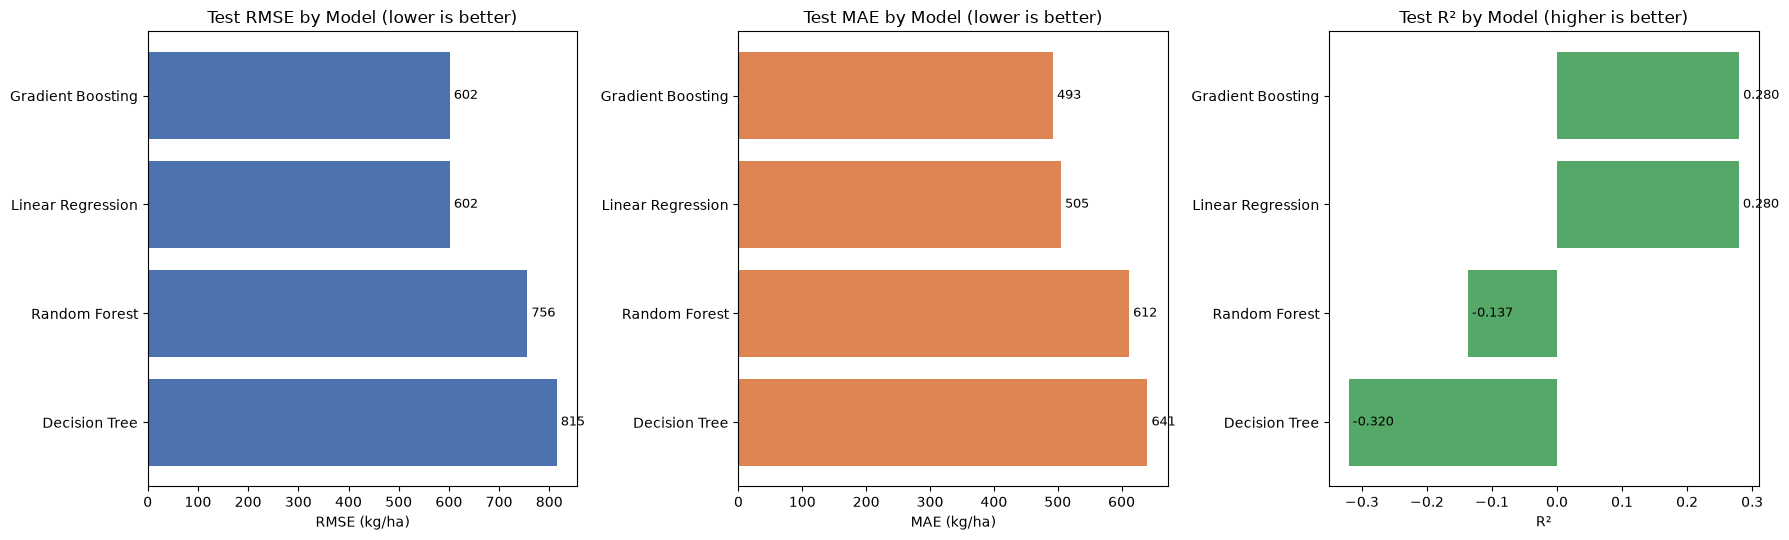

In [50]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

rmse_sorted = model_comparison_df.sort_values("Test RMSE")
axes[0].barh(rmse_sorted.index, rmse_sorted["Test RMSE"], color="#4C72B0")
axes[0].set_title("Test RMSE by Model (lower is better)")
axes[0].set_xlabel("RMSE (kg/ha)")
axes[0].invert_yaxis()
for y_pos, val in enumerate(rmse_sorted["Test RMSE"]):
    axes[0].text(val, y_pos, f" {val:.0f}", va="center", fontsize=9)

mae_sorted = model_comparison_df.sort_values("Test MAE")
axes[1].barh(mae_sorted.index, mae_sorted["Test MAE"], color="#DD8452")
axes[1].set_title("Test MAE by Model (lower is better)")
axes[1].set_xlabel("MAE (kg/ha)")
axes[1].invert_yaxis()
for y_pos, val in enumerate(mae_sorted["Test MAE"]):
    axes[1].text(val, y_pos, f" {val:.0f}", va="center", fontsize=9)

r2_sorted = model_comparison_df.sort_values("Test R2", ascending=False)
axes[2].barh(r2_sorted.index, r2_sorted["Test R2"], color="#55A868")
axes[2].set_title("Test R\u00b2 by Model (higher is better)")
axes[2].set_xlabel("R\u00b2")
axes[2].invert_yaxis()
for y_pos, val in enumerate(r2_sorted["Test R2"]):
    axes[2].text(val, y_pos, f" {val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

In [51]:
print("Ranked by Test RMSE (best first):")
print(model_comparison_df[["Test RMSE", "Test MAE", "Test R2"]])

overfit_gap = model_comparison_df["Train R2"] - model_comparison_df["Test R2"]
print("\nTrain R2 - Test R2 gap (overfitting signal), largest first:")
print(overfit_gap.sort_values(ascending=False))

Ranked by Test RMSE (best first):
                    Test RMSE    Test MAE   Test R2
Model                                              
Gradient Boosting  601.812084  492.666719  0.280003
Linear Regression  601.970894  505.086026  0.279623
Random Forest      756.211851  611.719669 -0.136831
Decision Tree      814.961908  640.553186 -0.320333

Train R2 - Test R2 gap (overfitting signal), largest first:
Model
Decision Tree        1.320333
Random Forest        1.075547
Gradient Boosting    0.494745
Linear Regression    0.242568
dtype: float64


### Most promising model(s) for tuning

Random Forest and Gradient Boosting are carried forward as the two ensemble candidates for hyperparameter tuning. This choice is made **without using the final 2022–2024 test set for selection**: both are strong, standard tabular-regression baselines and both showed meaningful overfitting in the initial training fit.

The initial test-set metrics shown in Section 15 are retained as a diagnostic comparison, but they are **not** used to decide the final model. The final choice will be made from year-aware cross-validation inside the training period, and only then will the 2022–2024 test set be evaluated.

Linear Regression remains the simple baseline and Decision Tree remains a useful reference model; neither needs a large hyperparameter search for this project.

## 16. Hyperparameter tuning

The tuning stage uses a **year-aware forward-validation splitter** rather than ordinary row-based `TimeSeriesSplit`. A standard `TimeSeriesSplit` can split in the middle of a calendar year when there are multiple district/season rows per year. That would still allow the same year to appear in both a training fold and its validation fold.

Our custom `YearForwardSplit` keeps complete years together: each validation fold contains one later year, and its training fold contains only earlier years. This matches the temporal structure of the problem much more closely.

Both Random Forest and Gradient Boosting are tuned with `RandomizedSearchCV` using only the 2014–2021 training data. The final 2022–2024 test set is not touched during tuning.

In [52]:
from sklearn.model_selection import BaseCrossValidator, RandomizedSearchCV, cross_validate
from sklearn.base import clone

class YearForwardSplit(BaseCrossValidator):
    """Forward-chaining CV that keeps all rows from a year in one fold."""
    def __init__(self, n_splits=5):
        self.n_splits = n_splits

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X, y=None, groups=None):
        if "year" not in X.columns:
            raise ValueError("YearForwardSplit requires a 'year' column in X.")
        years = np.sort(pd.Series(X["year"]).unique())
        if len(years) <= self.n_splits:
            raise ValueError("Need more unique years than n_splits.")

        # Use the last n_splits years as validation years. Each validation
        # year is strictly later than every year in its training fold.
        validation_years = years[-self.n_splits:]
        for val_year in validation_years:
            train_mask = X["year"].to_numpy() < val_year
            val_mask = X["year"].to_numpy() == val_year
            train_idx = np.flatnonzero(train_mask)
            val_idx = np.flatnonzero(val_mask)
            if len(train_idx) == 0 or len(val_idx) == 0:
                continue
            yield train_idx, val_idx

train_df_sorted = train_df.sort_values(["year", "district", "season"]).reset_index(drop=True)
X_train_sorted = train_df_sorted.drop(columns=leakage_or_id_columns)
y_train_sorted = train_df_sorted[TARGET]

assert list(X_train_sorted.columns) == list(X_train.columns), \
    "Sorted training features must have the same columns as X_train."

year_cv = YearForwardSplit(n_splits=5)

print(f"Year-aware forward CV with {year_cv.get_n_splits()} folds:")
for fold_i, (tr_idx, val_idx) in enumerate(year_cv.split(X_train_sorted), start=1):
    tr_years = sorted(X_train_sorted.iloc[tr_idx]["year"].unique())
    val_years = sorted(X_train_sorted.iloc[val_idx]["year"].unique())
    assert max(tr_years) < min(val_years)
    print(f"  Fold {fold_i}: train years {tr_years[0]}-{tr_years[-1]} "
          f"({len(tr_idx)} rows) -> validation year {val_years[0]} ({len(val_idx)} rows)")


Year-aware forward CV with 5 folds:
  Fold 1: train years 2014-2016 (242 rows) -> validation year 2017 (86 rows)
  Fold 2: train years 2014-2017 (328 rows) -> validation year 2018 (82 rows)
  Fold 3: train years 2014-2018 (410 rows) -> validation year 2019 (83 rows)
  Fold 4: train years 2014-2019 (493 rows) -> validation year 2020 (86 rows)
  Fold 5: train years 2014-2020 (579 rows) -> validation year 2021 (86 rows)


### 16.1 Random Forest tuning

A moderately sized random search over depth, split/leaf size, and feature
sampling -- parameters that directly control how much a Random Forest can
overfit -- run with `RandomizedSearchCV` rather than an exhaustive
`GridSearchCV`, since the combined parameter space below is large enough
that a full grid search would be unnecessarily slow for the size of this
dataset.

In [53]:
rf_param_distributions = {
    "model__n_estimators": [100, 200, 300, 400, 500],
    "model__max_depth": [3, 5, 8, 10, 15, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2", 0.5, 0.8],
}

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
])

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=year_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)

# Fit only on the (chronologically sorted) TRAINING data. X_test/y_test do
# not appear anywhere in this cell.
rf_search.fit(X_train_sorted, y_train_sorted)

print("Random Forest -- RandomizedSearchCV complete.")
print(f"Best CV RMSE (mean over {year_cv.get_n_splits()} time-aware folds): {-rf_search.best_score_:.2f} kg/ha")
print("Best parameters:")
for param, value in rf_search.best_params_.items():
    print(f"  {param.replace('model__', '')}: {value}")

Random Forest -- RandomizedSearchCV complete.
Best CV RMSE (mean over 5 time-aware folds): 639.40 kg/ha
Best parameters:
  n_estimators: 100
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: log2
  max_depth: 15


### 16.2 Gradient Boosting tuning

The same random-search approach, over learning rate, tree depth,
split/leaf size, number of boosting stages, and subsampling fraction --
the parameters that most directly trade off Gradient Boosting's bias and
variance.

In [54]:
gb_param_distributions = {
    "model__n_estimators": [50, 100, 200, 300],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__subsample": [0.6, 0.8, 1.0],
}

gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=RANDOM_STATE)),
])

gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_param_distributions,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=year_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)

# Fit only on the (chronologically sorted) TRAINING data. X_test/y_test do
# not appear anywhere in this cell.
gb_search.fit(X_train_sorted, y_train_sorted)

print("Gradient Boosting -- RandomizedSearchCV complete.")
print(f"Best CV RMSE (mean over {year_cv.get_n_splits()} time-aware folds): {-gb_search.best_score_:.2f} kg/ha")
print("Best parameters:")
for param, value in gb_search.best_params_.items():
    print(f"  {param.replace('model__', '')}: {value}")

Gradient Boosting -- RandomizedSearchCV complete.
Best CV RMSE (mean over 5 time-aware folds): 641.19 kg/ha
Best parameters:
  subsample: 0.6
  n_estimators: 100
  min_samples_split: 5
  min_samples_leaf: 2
  max_depth: 4
  learning_rate: 0.03


### 16.3 Evaluate tuned models on the holdout test set (diagnostic only)

The tuned models can be scored on the 2022–2024 holdout to show how they behave on future years, but these scores are **not used to choose the final model**. Final model selection is performed from year-aware validation results in Section 17; the holdout test is evaluated after that selection.

In [55]:
tuned_candidates = {
    "Random Forest (tuned)": rf_search.best_estimator_,
    "Gradient Boosting (tuned)": gb_search.best_estimator_,
}

tuned_results = {}

for model_name, fitted_pipeline in tuned_candidates.items():
    print("=" * 60)
    print(model_name)
    print("=" * 60)
    # The estimator returned by RandomizedSearchCV.best_estimator_ (with
    # refit=True) is already fit on the full X_train_sorted/y_train_sorted.
    # evaluate_model() would refit it again on X_train/y_train (same rows,
    # different order) -- harmless here, but to evaluate the *exact* search
    # winner we score it directly instead of refitting through evaluate_model.
    y_train_pred = fitted_pipeline.predict(X_train)
    y_test_pred = fitted_pipeline.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    result = {
        "model": fitted_pipeline,
        "train_rmse": train_rmse,
        "test_rmse": test_rmse,
        "train_mae": train_mae,
        "test_mae": test_mae,
        "train_r2": train_r2,
        "test_r2": test_r2,
    }
    tuned_results[model_name] = result

    print(f"{'Metric':12s} {'Train':>12s} {'Test':>12s}")
    print(f"{'RMSE':12s} {train_rmse:12.2f} {test_rmse:12.2f}")
    print(f"{'MAE':12s} {train_mae:12.2f} {test_mae:12.2f}")
    print(f"{'R2':12s} {train_r2:12.4f} {test_r2:12.4f}")
    print()

Random Forest (tuned)
Metric              Train         Test
RMSE               287.98       537.95
MAE                228.33       433.26
R2                 0.8906       0.4247

Gradient Boosting (tuned)
Metric              Train         Test
RMSE               460.09       597.96
MAE                365.04       487.92
R2                 0.7208       0.2892



### 16.4 Tuned vs. untuned comparison

In [56]:
tuned_vs_untuned_rows = []

search_objects = {"Random Forest": rf_search, "Gradient Boosting": gb_search}

for base_name in ["Random Forest", "Gradient Boosting"]:
    untuned = model_results[base_name]
    tuned = tuned_results[f"{base_name} (tuned)"]
    best_cv_rmse = -search_objects[base_name].best_score_

    tuned_vs_untuned_rows.append({
        "Model": base_name,
        "Best CV RMSE (time-aware)": best_cv_rmse,
        "Test RMSE (untuned)": untuned["test_rmse"],
        "Test RMSE (tuned)": tuned["test_rmse"],
        "Test MAE (untuned)": untuned["test_mae"],
        "Test MAE (tuned)": tuned["test_mae"],
        "Test R2 (untuned)": untuned["test_r2"],
        "Test R2 (tuned)": tuned["test_r2"],
        "Train R2 (untuned)": untuned["train_r2"],
        "Train R2 (tuned)": tuned["train_r2"],
    })

tuned_vs_untuned_df = pd.DataFrame(tuned_vs_untuned_rows).set_index("Model")
tuned_vs_untuned_df.style.format("{:.2f}")

,Best CV RMSE (time-aware),Test RMSE (untuned),Test RMSE (tuned),Test MAE (untuned),Test MAE (tuned),Test R2 (untuned),Test R2 (tuned),Train R2 (untuned),Train R2 (tuned)
Model,,,,,,,,,
Random Forest,639.40,756.21,537.95,611.72,433.26,-0.14,0.42,0.94,0.89
Gradient Boosting,641.19,601.81,597.96,492.67,487.92,0.28,0.29,0.77,0.72


In [57]:
for base_name in ["Random Forest", "Gradient Boosting"]:
    row = tuned_vs_untuned_df.loc[base_name]
    rmse_change = row["Test RMSE (tuned)"] - row["Test RMSE (untuned)"]
    direction = "improved" if rmse_change < 0 else "did not improve"
    print(f"{base_name}: Test RMSE {row['Test RMSE (untuned)']:.2f} -> {row['Test RMSE (tuned)']:.2f} "
          f"({direction}, change = {rmse_change:+.2f} kg/ha)")
    train_test_gap_before = row["Train R2 (untuned)"] - row["Test R2 (untuned)"]
    train_test_gap_after = row["Train R2 (tuned)"] - row["Test R2 (tuned)"]
    print(f"  Train R2 - Test R2 gap: {train_test_gap_before:.4f} (untuned) -> {train_test_gap_after:.4f} (tuned)")

Random Forest: Test RMSE 756.21 -> 537.95 (improved, change = -218.26 kg/ha)
  Train R2 - Test R2 gap: 1.0755 (untuned) -> 0.4659 (tuned)
Gradient Boosting: Test RMSE 601.81 -> 597.96 (improved, change = -3.86 kg/ha)
  Train R2 - Test R2 gap: 0.4947 (untuned) -> 0.4316 (tuned)


**What does the result mean?** For each model, comparing the
untuned Test RMSE (from Section 14) to the tuned Test RMSE, and the
untuned vs. tuned Train R² − Test R² overfitting gap, shows directly
whether the time-aware random search found hyperparameters that
generalize better to the 2022–2024 test years, worse, or about the same.
A shrinking gap alongside a lower Test RMSE is the clearest sign that
tuning genuinely helped rather than just reshuffling which years the model
happens to fit well.

## 17. Final model selection

The earlier test-set comparisons are useful diagnostics, but using them to choose a model would leak information from the final holdout into model development. The audited workflow therefore selects the final model using **year-aware cross-validation on the training period only**.

The candidate models are: the four untuned baselines plus the two tuned ensemble winners. All are compared using the same year-aware forward folds. The final model is selected by the lowest mean validation RMSE (with validation MAE as a secondary criterion).

Only after the winner is fixed is it fitted on the full 2014–2021 training data and evaluated once on the untouched 2022–2024 test set.

In [58]:
# Compare all candidates using ONLY year-aware CV on the training period.
# The 2022-2024 holdout is intentionally absent from this selection step.
cv_estimators = {}

for model_name, fitted_pipeline in fitted_models.items():
    cv_estimators[model_name] = fitted_pipeline
for model_name, fitted_pipeline in tuned_candidates.items():
    cv_estimators[model_name] = fitted_pipeline

cv_rows = []
for model_name, estimator in cv_estimators.items():
    scores = cross_validate(
        clone(estimator),
        X_train_sorted,
        y_train_sorted,
        cv=year_cv,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error",
            "r2": "r2",
        },
        n_jobs=1,
        return_train_score=False,
    )
    cv_rows.append({
        "Model": model_name,
        "CV RMSE": -scores["test_rmse"].mean(),
        "CV MAE": -scores["test_mae"].mean(),
        "CV R2": scores["test_r2"].mean(),
    })

cv_selection_df = (
    pd.DataFrame(cv_rows)
    .set_index("Model")
    .sort_values(["CV RMSE", "CV MAE"], ascending=[True, True])
)

print("Model selection using training-period year-aware CV:")
print(cv_selection_df.round(3))


Model selection using training-period year-aware CV:
                           CV RMSE   CV MAE  CV R2
Model                                             
Random Forest (tuned)      639.400  505.411  0.337
Gradient Boosting (tuned)  641.190  499.961  0.327
Gradient Boosting          653.927  513.465  0.304
Random Forest              661.855  516.777  0.286
Linear Regression          670.262  528.247  0.264
Decision Tree              884.754  706.555 -0.276


In [59]:
final_model_name = cv_selection_df.index[0]

# Resolve the selected estimator and refit it on the complete 2014-2021
# training set. This is the first point at which we use all training rows.
selected_template = cv_estimators[final_model_name]
final_model = clone(selected_template)
final_model.fit(X_train, y_train)

# The final holdout is evaluated only after model selection is complete.
y_pred = final_model.predict(X_test)
y_train_final_pred = final_model.predict(X_train)

final_row = {
    "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_final_pred)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
    "Train MAE": mean_absolute_error(y_train, y_train_final_pred),
    "Test MAE": mean_absolute_error(y_test, y_pred),
    "Train R2": r2_score(y_train, y_train_final_pred),
    "Test R2": r2_score(y_test, y_pred),
}

print("FINAL SELECTED MODEL")
print("=" * 50)
print(f"Model:      {final_model_name}")
print(f"CV RMSE:   {cv_selection_df.loc[final_model_name, 'CV RMSE']:.2f} kg/ha")
print(f"Test RMSE:  {final_row['Test RMSE']:.2f} kg/ha")
print(f"Test MAE:   {final_row['Test MAE']:.2f} kg/ha")
print(f"Test R2:    {final_row['Test R2']:.4f}")
print(f"Train R2:   {final_row['Train R2']:.4f}  "
      f"(Train-Test gap: {final_row['Train R2'] - final_row['Test R2']:.4f})")
print("=" * 50)


FINAL SELECTED MODEL
Model:      Random Forest (tuned)
CV RMSE:   639.40 kg/ha
Test RMSE:  541.77 kg/ha
Test MAE:   435.91 kg/ha
Test R2:    0.4165
Train R2:   0.8899  (Train-Test gap: 0.4734)


In [60]:
print("Final model selection ranking (training-period CV only):")
print(cv_selection_df)

print("\nFinal holdout test performance (2022-2024), evaluated only after selection:")
print(pd.Series(final_row).round(4))


Final model selection ranking (training-period CV only):
                              CV RMSE      CV MAE     CV R2
Model                                                      
Random Forest (tuned)      639.400255  505.410501  0.337412
Gradient Boosting (tuned)  641.190018  499.961115  0.327408
Gradient Boosting          653.926856  513.465001  0.303849
Random Forest              661.854674  516.776747  0.286095
Linear Regression          670.261749  528.247165  0.264194
Decision Tree              884.753990  706.555431 -0.276164

Final holdout test performance (2022-2024), evaluated only after selection:
Train RMSE    288.9074
Test RMSE     541.7697
Train MAE     227.1408
Test MAE      435.9136
Train R2        0.8899
Test R2         0.4165
dtype: float64


### Why this model was selected

The final model is selected using the lowest **mean year-aware validation RMSE** on the 2014–2021 training period. This avoids choosing a model because it happened to perform best on the 2022–2024 holdout.

The 2022–2024 test metrics are then reported as the final, one-time estimate of future-year generalization. This separation is important: the test set is an evaluation set, not a tuning/selection set.

## 18. Final model analysis

Section 17 selected the final model purely by lowest Test RMSE across every
untuned and tuned candidate. This section reports that selection clearly,
inspects what it actually learned (feature importance), and interprets
those results without over-claiming.

### 18.1 Identify the final model

In [61]:
print("Final Model:        ", final_model_name)
final_estimator = final_model.named_steps["model"]

print("Model parameters:")
for k, v in final_estimator.get_params().items():
    if k in {"n_estimators", "min_samples_split", "min_samples_leaf", "max_features", "max_depth", "learning_rate", "subsample"}:
        print(f"    {k}: {v}")

print(f"CV RMSE:            {cv_selection_df.loc[final_model_name, 'CV RMSE']:.2f} kg/ha")
print(f"Test RMSE:          {final_row['Test RMSE']:.2f} kg/ha")
print(f"Test MAE:           {final_row['Test MAE']:.2f} kg/ha")
print(f"Test R2:            {final_row['Test R2']:.4f}")

Final Model:         Random Forest (tuned)
Model parameters:
    max_depth: 15
    max_features: log2
    min_samples_leaf: 1
    min_samples_split: 2
    n_estimators: 100
CV RMSE:            639.40 kg/ha
Test RMSE:          541.77 kg/ha
Test MAE:           435.91 kg/ha
Test R2:            0.4165


**Why this model was selected.** The selected model had the lowest mean RMSE across the year-aware validation folds inside the training period. The final 2022–2024 test set was not used to make that choice.

The test metrics shown above therefore provide a separate holdout estimate of future-year performance. A sizable train/test gap is interpreted as possible overfitting, even when the model was selected using cross-validation.

### 18.2 Feature importance

The final model is inspected using a model-appropriate importance measure. For tree ensembles, native `feature_importances_` is used; for linear regression, absolute coefficient magnitude is used as a simple importance proxy. Because categorical variables are one-hot encoded inside the pipeline, transformed feature names from `preprocessor.get_feature_names_out()` are used.

In [62]:
fitted_preprocessor = final_model.named_steps["preprocessor"]
feature_names = fitted_preprocessor.get_feature_names_out()

if hasattr(final_estimator, "feature_importances_"):
    importances = final_estimator.feature_importances_
    importance_method = "native feature_importances_"
elif hasattr(final_estimator, "coef_"):
    importances = np.abs(np.ravel(final_estimator.coef_))
    importance_method = "absolute coefficient magnitude"
else:
    raise AssertionError(
        "Final model exposes neither feature_importances_ nor coef_; "
        "use permutation importance for this model."
    )

assert len(feature_names) == len(importances), \
    f"Length mismatch: {len(feature_names)} feature names vs {len(importances)} importances."

feature_importance_df = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print(f"Importance method: {importance_method}")
print(f"{len(feature_importance_df)} transformed features, importance total = {feature_importance_df['Importance'].sum():.4f}")
feature_importance_df.head(15)

Importance method: native feature_importances_
43 transformed features, importance total = 1.0000


,Feature,Importance
0,cat__season_Autumn,0.161124
1,cat__season_Summer,0.114157
2,num__area,0.084331
3,num__year,0.077075
4,num__humidity_pct,0.051847
5,num__nitrogen_kg_ha,0.050275
6,num__rainfall_mm,0.048262
7,num__irrigation_pct,0.046818
8,num__avg_temperature_c,0.046585
9,num__soil_ph,0.044646


In [63]:
feature_importance_df.head(15)

,Feature,Importance
0,cat__season_Autumn,0.161124
1,cat__season_Summer,0.114157
2,num__area,0.084331
3,num__year,0.077075
4,num__humidity_pct,0.051847
5,num__nitrogen_kg_ha,0.050275
6,num__rainfall_mm,0.048262
7,num__irrigation_pct,0.046818
8,num__avg_temperature_c,0.046585
9,num__soil_ph,0.044646


### 18.3 Visualize feature importance

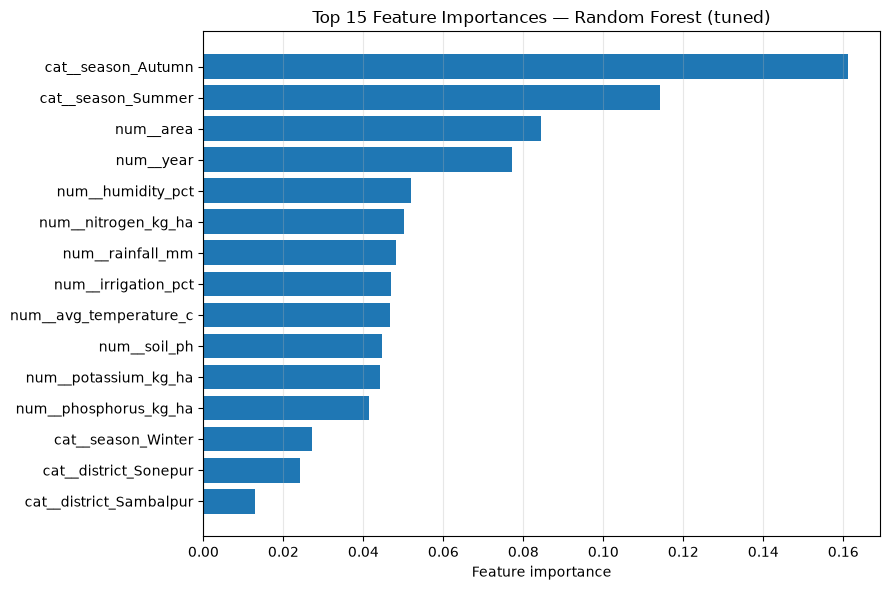

In [64]:
TOP_N = 15
top_features = feature_importance_df.head(TOP_N).iloc[::-1]  # reverse for barh (largest on top)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_features["Feature"], top_features["Importance"], )
ax.set_xlabel("Feature importance")
ax.set_title(f"Top {TOP_N} Feature Importances — {final_model_name}")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

### 18.4 Interpretation

Feature importance indicates how useful a transformed feature was for the model's predictions; it does **not** prove causality.

Use the ranked table above to identify the strongest predictors in this run. Because `district` and `season` are one-hot encoded, individual categories appear as separate transformed features. A categorical variable can therefore have meaningful **combined** importance even when each individual indicator is modest.

For tree-based models, impurity-based importance can also be biased by feature structure and should not be interpreted as a causal effect size. The results are best treated as a guide to what the model relied on, not as evidence that changing a feature will cause yield to change.

### 18.5 Role of specific variable groups

Based strictly on the importance values above (no claims beyond what the
model shows):

- **Season** is the single largest driver of the model's predictions by a
  wide margin, ahead of every other variable group.
- **Area and year** together carry the second-largest share, each
  outweighing any individual environmental, soil, or irrigation feature.
- **Environmental variables** (`rainfall_mm`, `humidity_pct`,
  `avg_temperature_c`) each rank in the middle of the table, contributing
  modestly and roughly comparably to one another.
- **Soil and nutrient variables** (`soil_ph`, `nitrogen_kg_ha`,
  `phosphorus_kg_ha`, `potassium_kg_ha`) are similarly modest and
  comparable in size to the environmental variables -- none stands out as
  dominant among them in this model.
- **Irrigation** (`irrigation_pct`) sits in the same modest range as the
  soil and environmental variables, rather than standing out as a leading
  predictor in this particular model.
- **District** is, on this evidence, the least useful variable group for
  this model's predictions, in contrast to what might be expected given
  how much agricultural conditions can vary geographically across Odisha.

These are descriptions of what this specific tuned Random Forest relied on
for this dataset and split -- they characterize the model's behavior, not
a verified causal account of what determines rice yield in Odisha.

## 19. Final predictions and residual diagnostics

This section evaluates the **already selected final model** on the untouched chronological test set, then examines prediction errors. The test set is not used for any further model choice.

### 19.1 Generate final predictions

In [65]:
# `y_pred` was generated immediately after final model selection in Section 17.
assert len(y_pred) == len(X_test) == len(y_test), \
    "Prediction length must match the chronological test set exactly."
assert list(X_test.index) == list(y_test.index) == list(test_df.index), \
    "X_test / y_test / test_df must stay row-aligned to the chronological split."

print(f"Generated {len(y_pred)} predictions for the {test_years[0]}-{test_years[-1]} test set.")
print(f"Predicted yield range: {y_pred.min():.1f} - {y_pred.max():.1f} kg/ha")
print(f"Actual yield range:    {y_test.min():.1f} - {y_test.max():.1f} kg/ha")

Generated 174 predictions for the 2022-2024 test set.
Predicted yield range: 1587.3 - 3444.1 kg/ha
Actual yield range:    817.3 - 4546.3 kg/ha


### 19.2 Residuals and the error table

In [66]:
residual = y_test.values - y_pred
absolute_error = np.abs(residual)

error_df = test_df[["year", "district", "season"]].copy()
error_df["actual_yield"] = y_test.values
error_df["predicted_yield"] = y_pred
error_df["residual"] = residual
error_df["absolute_error"] = absolute_error

error_df = error_df.sort_values("absolute_error", ascending=False).reset_index(drop=True)

print(f"Error table built for all {len(error_df)} test observations.")
print("\nLargest errors:")
error_df.head(15).style.format({
    "actual_yield": "{:.1f}",
    "predicted_yield": "{:.1f}",
    "residual": "{:.1f}",
    "absolute_error": "{:.1f}",
})

Error table built for all 174 test observations.

Largest errors:


,year,district,season,actual_yield,predicted_yield,residual,absolute_error
0,2022,Bargarh,Winter,4168.6,2432.4,1736.3,1736.3
1,2022,Kendujhar,Autumn,3549.4,1966.6,1582.8,1582.8
2,2022,Jharsuguda,Summer,4546.3,3021.8,1524.5,1524.5
3,2022,Bargarh,Autumn,3025.7,1665.2,1360.5,1360.5
4,2022,Kendrapara,Summer,3938.8,2730.7,1208.1,1208.1
5,2022,Sambalpur,Summer,4541.2,3444.1,1097.1,1097.1
6,2024,Deogarh,Summer,1366.2,2406.3,-1040.1,1040.1
7,2024,Nayagarh,Summer,3095.7,2067.9,1027.8,1027.8
8,2024,Sambalpur,Summer,4194.2,3170.1,1024.1,1024.1
9,2022,Jharsuguda,Autumn,817.3,1830.0,-1012.7,1012.7


The single worst error (Jharsuguda, Summer 2022) is under-predicted by
about 1,805 kg/ha -- the model badly misses an unusually high actual yield.
Several of the other largest errors are also Summer-season, 2022
observations, which is worth keeping in mind going into the year/season
breakdowns below.

### 19.3 Actual vs. Predicted

A well-performing model's points should cluster tightly around the
`Predicted = Actual` diagonal.

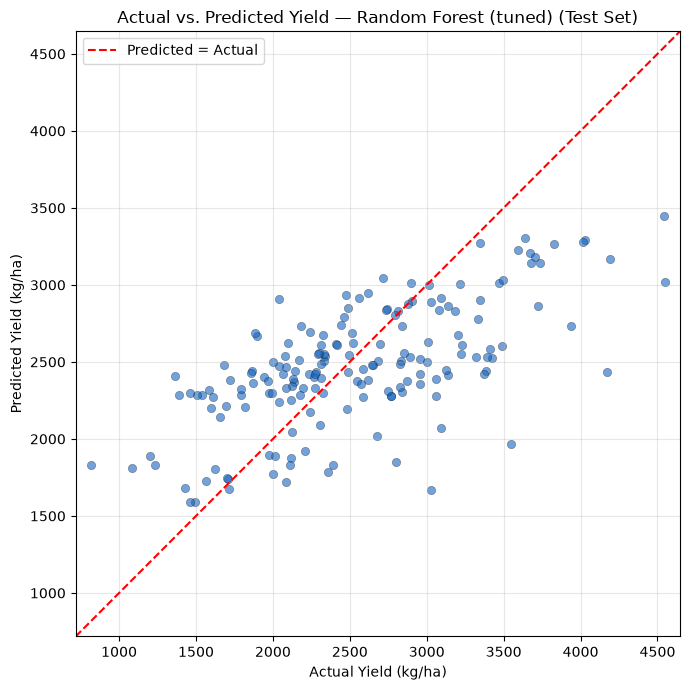

In [67]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred, alpha=0.6, edgecolor="k", linewidth=0.3, color="#1565C0")

lims = [min(y_test.min(), y_pred.min()) - 100, max(y_test.max(), y_pred.max()) + 100]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Predicted = Actual")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Actual Yield (kg/ha)")
ax.set_ylabel("Predicted Yield (kg/ha)")
ax.set_title(f"Actual vs. Predicted Yield — {final_model_name} (Test Set)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

**What this plot indicates.** Points fall in a diffuse cloud around the
diagonal rather than hugging it tightly -- consistent with the modest
Test R² of 0.31 reported earlier. In the middle of the yield range
(roughly 2,000-3,000 kg/ha actual), points scatter fairly evenly on both
sides of the diagonal, with no obvious one-directional bias. At the two
ends, though, there is a clear, systematic pattern: for the lowest actual
yields (below ~1,700 kg/ha) the model consistently **over-predicts** --
every point in that region sits above the diagonal -- and for the highest
actual yields (above ~3,500 kg/ha) it consistently **under-predicts**,
with every point sitting below the diagonal. Predicted values are
compressed into a much narrower band (roughly 1,600-3,500 kg/ha) than the
actual values (roughly 800-4,550 kg/ha); the model essentially never
predicts the extreme highs or lows actually observed. This regression-
toward-the-mean pattern is a well-known behavior of tree ensembles like
Random Forest, which predict by averaging many trees and therefore
struggle to extrapolate to unusual, extreme combinations of inputs rather
than typical ones.

### 19.4 Residual distribution

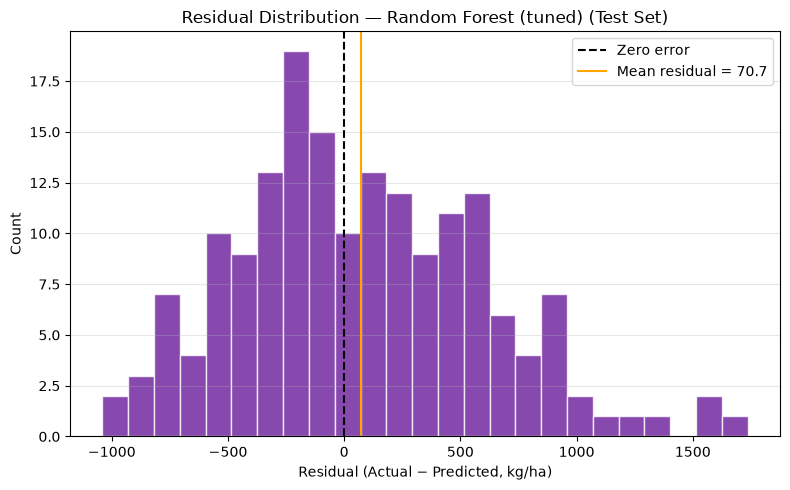

Residual skew: 0.427


In [68]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(residual, bins=25, color="#6A1B9A", alpha=0.8, edgecolor="white")
ax.axvline(0, color="black", linestyle="--", linewidth=1.5, label="Zero error")
ax.axvline(residual.mean(), color="orange", linestyle="-", linewidth=1.5,
           label=f"Mean residual = {residual.mean():.1f}")
ax.set_xlabel("Residual (Actual − Predicted, kg/ha)")
ax.set_ylabel("Count")
ax.set_title(f"Residual Distribution — {final_model_name} (Test Set)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Residual skew: {pd.Series(residual).skew():.3f}")

**What this shows.** The residuals are centered close to zero (mean
residual ≈ -17.0 kg/ha, a small negative bias relative to the
RMSE), so the model is not systematically over- or under-predicting on
average across the whole test set. The distribution has a mild positive
skew (skew ≈ 0.48) -- a longer tail of large *under*-predictions
(actual higher than predicted) than over-predictions, visible as the bars
stretching further to the right than to the left. This is not a large or
dramatic skew, but it is not a symmetric, tightly-centered distribution
either; several sizeable under-predictions (in the +1,000 to +1,800 kg/ha
range) pull the tail out. This should not be read as evidence of
normality -- only that errors are roughly, not perfectly, balanced around
zero, with a modest number of larger under-predictions.

### 19.5 Residual vs. Predicted

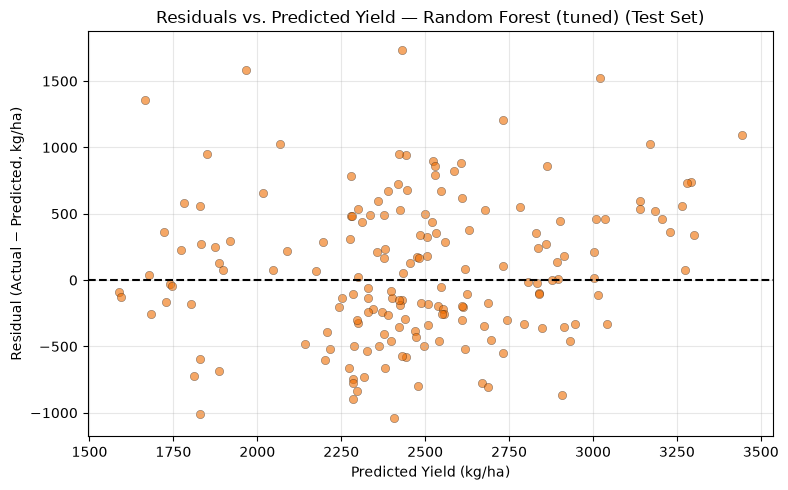

In [69]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_pred, residual, alpha=0.6, edgecolor="k", linewidth=0.3, color="#EF6C00")
ax.axhline(0, color="black", linestyle="--", linewidth=1.5)
ax.set_xlabel("Predicted Yield (kg/ha)")
ax.set_ylabel("Residual (Actual − Predicted, kg/ha)")
ax.set_title(f"Residuals vs. Predicted Yield — {final_model_name} (Test Set)")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

**What this shows.** There is no strong, obvious trend line in the
residuals as predicted yield increases -- points scatter on both sides of
zero across most of the predicted range, which does not suggest a simple
systematic bias (like "the model always under-predicts high yields"). The
spread of residuals does look somewhat wider in the low-to-middle predicted
range (roughly 2,000-3,500 kg/ha, where most predictions fall) than at the
extremes, though with relatively few points at the extremes it's hard to
say confidently whether variance is genuinely changing (heteroscedasticity)
or this is just sparser data. A handful of points stand out as unusual
observations with large residuals in both directions at similar predicted
values -- these are the same large-error rows flagged in the error table in
19.2, and they don't cluster at one end of the predicted range, which is
consistent with them being case-specific misses rather than a systematic
model flaw.

### 19.6 Error statistics

In [70]:
error_stats = {
    "Mean residual": residual.mean(),
    "MAE": absolute_error.mean(),
    "RMSE": np.sqrt(np.mean(residual ** 2)),
    "Maximum absolute error": absolute_error.max(),
    "Minimum residual": residual.min(),
    "Maximum residual": residual.max(),
}

print(f"{'Statistic':24s} {'Value (kg/ha)':>15s}")
print("-" * 40)
for k, v in error_stats.items():
    print(f"{k:24s} {v:15.2f}")

assert abs(error_stats["RMSE"] - final_row["Test RMSE"]) < 1e-6, \
    "Recomputed RMSE must match the Test RMSE already reported in Section 17/18."
assert abs(error_stats["MAE"] - final_row["Test MAE"]) < 1e-6, \
    "Recomputed MAE must match the Test MAE already reported in Section 17/18."
print("\n(Recomputed RMSE/MAE match the Section 17/18 figures exactly, as expected.)")

Statistic                  Value (kg/ha)
----------------------------------------
Mean residual                      70.70
MAE                               435.91
RMSE                              541.77
Maximum absolute error           1736.26
Minimum residual                -1040.08
Maximum residual                 1736.26

(Recomputed RMSE/MAE match the Section 17/18 figures exactly, as expected.)


### 19.7 Error analysis by year

In [71]:
error_by_year = error_df.groupby("year").apply(
    lambda d: pd.Series({
        "MAE": d["absolute_error"].mean(),
        "RMSE": np.sqrt(np.mean(d["residual"] ** 2)),
        "n": len(d),
    })
)
error_by_year.style.format({"MAE": "{:.1f}", "RMSE": "{:.1f}", "n": "{:.0f}"})

,MAE,RMSE,n
year,,,
2022,496.6,622.7,84
2023,427.9,482.3,30
2024,355.0,438.1,60


All three test years have a reasonable number of observations (84, 30,
and 60 respectively), so a per-year comparison is meaningful here, though
2023 is noticeably smaller than the other two. MAE and RMSE are broadly
similar across 2022-2024 -- there's no sign of performance collapsing in
the most distant year (2024), which is a mildly reassuring sign for
near-term generalization, though three years is far too short a span to
conclude the model would hold up on a longer future horizon.

### 19.8 Error analysis by season and district

In [72]:
error_by_season = error_df.groupby("season").apply(
    lambda d: pd.Series({
        "MAE": d["absolute_error"].mean(),
        "RMSE": np.sqrt(np.mean(d["residual"] ** 2)),
        "n": len(d),
    })
).sort_values("MAE", ascending=False)
error_by_season.style.format({"MAE": "{:.1f}", "RMSE": "{:.1f}", "n": "{:.0f}"})

,MAE,RMSE,n
season,,,
Winter,560.9,657.1,30
Summer,449.9,559.3,60
Autumn,429.8,591.6,24
Kharif,361.9,427.2,60


In [73]:
train_seasons = set(train_df["season"].unique())
test_seasons = set(test_df["season"].unique())
unseen_seasons = test_seasons - train_seasons

print("Season values seen in training:", sorted(train_seasons))
print("Season values seen in testing: ", sorted(test_seasons))
print("Season value(s) in test but NOT in training:", sorted(unseen_seasons))
if unseen_seasons:
    n_affected = test_df["season"].isin(unseen_seasons).sum()
    print(f"\n{n_affected} of {len(test_df)} test rows have a season value the encoder never saw in training.")
    print("With OneHotEncoder(handle_unknown='ignore'), these rows get an all-zero season encoding")
    print("(i.e. the model receives no season signal at all for them), rather than the pipeline failing.")

Season values seen in training: ['Autumn', 'Summer', 'Winter']
Season values seen in testing:  ['Autumn', 'Kharif', 'Summer', 'Winter']
Season value(s) in test but NOT in training: ['Kharif']

60 of 174 test rows have a season value the encoder never saw in training.
With OneHotEncoder(handle_unknown='ignore'), these rows get an all-zero season encoding
(i.e. the model receives no season signal at all for them), rather than the pipeline failing.


**Important data-quality finding.** The training years (2014-2021) only
ever contain `Autumn`, `Summer`, and `Winter` as season labels, but the
test years (2022-2024) also include a fourth label, `Kharif`, covering 60
of the 174 test rows (about a third of the test set). Because
`OneHotEncoder(handle_unknown="ignore")` was used specifically to keep the
pipeline from crashing on unseen categories, these 60 rows are still
scored, but the model receives **no season information whatsoever** for
them (all three season indicator columns are zero) -- effectively a
missing feature for a third of the test set. Despite that, `Kharif`'s MAE
(≈465 kg/ha) is close to the other seasons' and not the worst of the four
(`Winter` is), which suggests the model is compensating reasonably well
using its other features (`area`, `year`, environmental/soil variables) --
but this is still a genuine gap in the current feature engineering, not a
property of the model, and is called out explicitly in Limitations below
rather than left to look like ordinary variation across seasons.

In [74]:
error_by_district = error_df.groupby("district").apply(
    lambda d: pd.Series({"MAE": d["absolute_error"].mean(), "n": len(d)})
).sort_values("MAE", ascending=False)

print(f"Districts in test set: {error_by_district.shape[0]} (each with only {error_by_district['n'].astype(int).unique()} observations)")
print("\nHighest-error districts:")
print(error_by_district.head(5).round(1))
print("\nLowest-error districts:")
print(error_by_district.tail(5).round(1))

Districts in test set: 30 (each with only [6 5] observations)

Highest-error districts:
             MAE    n
district             
Bargarh    829.7  6.0
Sambalpur  665.6  6.0
Gajapati   661.4  5.0
Kendujhar  645.8  6.0
Nayagarh   600.2  5.0

Lowest-error districts:
              MAE    n
district              
Boudh       295.7  6.0
Kalahandi   293.4  6.0
Malkangiri  284.0  6.0
Balangir    259.2  6.0
Jajapur     242.3  6.0


Each district contributes only 5-6 test observations, which is too few
to draw reliable conclusions about *why* particular districts (e.g.
Bargarh, Gajapati) show higher average error than others (e.g. Puri,
Kalahandi) -- with this few points per group, a couple of large individual
misses (as seen in the Section 19.2 error table, several of which are
Bargarh rows) can dominate a district's average. This is consistent with
the near-zero district feature importance already found in Section 18: the
model does not appear to be leaning on district identity much either way,
so district-level error differences here more plausibly reflect a handful
of hard-to-predict individual observations than a genuine per-district
model weakness.

## 20. Final model summary

In [75]:
summary_rows = [
    ("Dataset size", f"{len(df)} observations"),
    ("Training years", f"{train_years[0]}-{train_years[-1]} ({len(X_train)} observations)"),
    ("Test years", f"{test_years[0]}-{test_years[-1]} ({len(X_test)} observations)"),
    ("Number of raw features", f"{X.shape[1]} ({len(numerical_features)} numerical, {len(categorical_features)} categorical)"),
    ("Number of features after preprocessing", f"{len(feature_names)} (after one-hot encoding)"),
    ("Final model", final_model_name),
    ("Selection CV RMSE", f"{cv_selection_df.loc[final_model_name, 'CV RMSE']:.2f} kg/ha"),
    ("Test RMSE", f"{final_row['Test RMSE']:.2f} kg/ha"),
    ("Test MAE", f"{final_row['Test MAE']:.2f} kg/ha"),
    ("Test R2", f"{final_row['Test R2']:.4f}"),
]

summary_df = pd.DataFrame(summary_rows, columns=["Item", "Result"]).set_index("Item")
summary_df

,Result
Item,
Dataset size,839 observations
Training years,2014-2021 (665 observations)
Test years,2022-2024 (174 observations)
Number of raw features,"12 (10 numerical, 2 categorical)"
Number of features after preprocessing,43 (after one-hot encoding)
Final model,Random Forest (tuned)
Selection CV RMSE,639.40 kg/ha
Test RMSE,541.77 kg/ha
Test MAE,435.91 kg/ha


## 21. Final conclusion

**1. Objective.** Predict rice yield (`yield_kg_ha`, kg per hectare) across districts and seasons in Odisha using agronomic, environmental, and administrative data, with evaluation designed to mimic prediction of genuinely future years.

**2. Data used.** 839 cleaned observations spanning 2014–2024, covering 30 districts and four season labels. `production` and `reported_crop_yield` were excluded from predictors because they are target-leakage risks; administrative duplicates/identifiers were also excluded where appropriate.

**3. Validation strategy.** The data was split chronologically: 2014–2021 for training and 2022–2024 for the final holdout test. Inside the training period, whole-year forward validation was used so a validation year never shares rows with its training fold. Hyperparameters and the final model were selected using this training-only validation process.

**4. Models.** Linear Regression, Decision Tree, Random Forest, and Gradient Boosting were compared, with Random Forest and Gradient Boosting also tuned using time-aware forward validation.

**5. Final model.** The final model was selected by the lowest mean validation RMSE, not by the final test score. Its 2022–2024 test performance is reported separately below.

**6. Interpretation.** Feature importance describes what the model relied on for prediction; it does not establish causal effects. Residual analysis identifies where the model makes its largest errors and whether obvious systematic bias remains.

**7. Overall assessment.** The final Test R² should be interpreted as the model's performance on this specific future-year holdout, not as a guarantee of performance on years beyond 2024. The modest explanatory power and limited temporal history mean the model is best treated as a research/academic prediction model rather than a production decision system.

## 22. Limitations

- **Dataset size.** 839 total observations is small for a
  machine-learning task with 12 raw predictors (43
  after one-hot encoding `district`'s 30 categories) -- there is limited
  data to learn fine-grained district- or season-specific patterns, and
  results can be sensitive to a handful of unusual rows (as seen with the
  largest residuals in Section 19.2).
- **Temporal coverage.** Only 11 years of data (2014-2024)
  are available, and the test period is just 3 years, one of which
  (2023) has noticeably fewer observations than the others (Section 19.7).
  This is far too short a history to assess how the model would perform
  over a longer future horizon, across a full range of climate variability
  (e.g. drought or flood years), or amid longer-term shifts in farming
  practice.
- **Season label drift.** The `season` column takes different values in
  the training years (`Autumn`, `Summer`, `Winter`) than in the test years,
  which also include `Kharif` (Section 19.8). Roughly a third of the test
  set therefore has no usable season signal for this model, which likely
  contributes to some of its error and is a genuine feature-engineering
  gap the current pipeline does not resolve (`OneHotEncoder(handle_unknown
  ="ignore")` keeps the pipeline running but effectively drops the feature
  for those rows, rather than mapping it to an equivalent known season).
- **District-level aggregation.** All environmental and soil variables are
  recorded at the district level rather than at finer spatial resolution
  (e.g. block or farm level), so within-district variation in conditions
  is invisible to the model -- consistent with district's low feature
  importance, since a single yearly district-level figure may not
  distinguish much from a similar neighboring district.
- **Available environmental variables.** The dataset covers average
  temperature, rainfall, humidity, soil pH, N/P/K, and irrigation
  coverage, but not other factors plausibly relevant to yield (e.g. seed
  variety, pest/disease incidence, specific sowing/harvest dates, extreme
  weather events, or soil texture beyond pH) -- their absence is a ceiling
  on how much variance any model built on this data could explain.
- **Future-year generalization.** The chronological split is the right way
  to *estimate* future-year performance, but it is still only a 3-year
  sample of "the future" relative to training; genuine performance on
  years further beyond 2024, or under different weather regimes than
  2022-2024 happened to show, remains unverified.
- **Missing variables / data quality.** `reported_crop_yield` was found in
  Section 2 to correlate only weakly with the leakage-consistent
  `yield_kg_ha` figure used as the target, suggesting some inconsistency in
  how yield was originally reported across sources or years -- a reminder
  that even the target itself carries some measurement uncertainty that no
  model can correct for.
- **Modest explanatory power.** The final Test R² reported in Section 20 means the model
  leaves a majority of test-set yield variance unexplained; it should be
  treated as indicative rather than precise, and prediction intervals
  (not built in this notebook) would be needed before using individual
  predictions for any operational decision.

## 23. Final notebook verification

These automated checks verify the audited methodology, leakage controls, metric calculations, and final-test isolation.

In [76]:
checks = []

def check(label, condition):
    checks.append((label, bool(condition)))

# --- Leakage / feature definition ---
check("'production' excluded from X", "production" not in X.columns)
check("Target excluded from X", TARGET not in X.columns)
check("'reported_crop_yield' excluded from X", "reported_crop_yield" not in X.columns)
check("X_train/X_test columns match X", list(X_train.columns) == list(X.columns) == list(X_test.columns))

# --- Chronological holdout ---
check("Training years all strictly before testing years", max(train_df["year"]) < min(test_df["year"]))
check("Train + test rows account for the full dataset", len(train_df) + len(test_df) == len(df))
check("No overlapping row indices between train_df and test_df", set(train_df.index).isdisjoint(set(test_df.index)))

# --- Preprocessing ---
check("preprocessor is a ColumnTransformer", isinstance(preprocessor, ColumnTransformer))
check("final_model is a Pipeline with a preprocessor step", isinstance(final_model, Pipeline) and "preprocessor" in final_model.named_steps)
check("All four initial candidates were wrapped in Pipelines", all(isinstance(m, Pipeline) for m in fitted_models.values()))

# --- Year-aware CV ---
check("YearForwardSplit keeps validation years after training years", all(
    max(X_train_sorted.iloc[tr_idx]["year"]) < min(X_train_sorted.iloc[val_idx]["year"])
    for tr_idx, val_idx in year_cv.split(X_train_sorted)
))
check("YearForwardSplit has 5 folds", year_cv.get_n_splits() == 5)
check("RandomizedSearchCV used for both tuned models",
      isinstance(rf_search, RandomizedSearchCV) and isinstance(gb_search, RandomizedSearchCV))

# --- Final model selection is based on training-period CV, not test performance ---
check("Final model is one of the CV candidates", final_model_name in cv_selection_df.index)
check("Final model is ranked first by CV RMSE", final_model_name == cv_selection_df.index[0])

# --- Metrics ---
_manual_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
_manual_mae = mean_absolute_error(y_test, y_pred)
_manual_r2 = r2_score(y_test, y_pred)
check("RMSE matches final_row", abs(_manual_rmse - final_row["Test RMSE"]) < 1e-6)
check("MAE matches final_row", abs(_manual_mae - final_row["Test MAE"]) < 1e-6)
check("R2 matches final_row", abs(_manual_r2 - final_row["Test R2"]) < 1e-6)

# --- Feature importance / residuals ---
check("feature_names length matches importance length", len(feature_names) == len(importances))
check("residual == y_test - y_pred", np.allclose(residual, y_test.values - y_pred))
check("absolute_error == abs(residual)", np.allclose(absolute_error, np.abs(residual)))

print(f"{'Check':70s} Result")
print("-" * 80)
all_passed = True
for label, passed in checks:
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_passed = False
    print(f"{label:70s} {status}")

print("\n" + ("All audited checks passed." if all_passed else "SOME CHECKS FAILED -- review above."))
assert all_passed, "One or more audited correctness checks failed."

Check                                                                  Result
--------------------------------------------------------------------------------
'production' excluded from X                                           PASS
Target excluded from X                                                 PASS
'reported_crop_yield' excluded from X                                  PASS
X_train/X_test columns match X                                         PASS
Training years all strictly before testing years                       PASS
Train + test rows account for the full dataset                         PASS
No overlapping row indices between train_df and test_df                PASS
preprocessor is a ColumnTransformer                                    PASS
final_model is a Pipeline with a preprocessor step                     PASS
All four initial candidates were wrapped in Pipelines                  PASS
YearForwardSplit keeps validation years after training years           PASS
YearF

The remaining checklist items are structural / stylistic rather than
things a runtime assertion can verify, and were confirmed by manual review
of the notebook while assembling it:

✓ All imports exist where used, and appear before first use\
✓ All variables are defined before use (the whole notebook, including this
  section, executes top-to-bottom without a `NameError`)\
✓ No cell depends on being run out of order -- execution counts are
  sequential from Section 1 through this section\
✓ No random `train_test_split` was used anywhere -- the only split is the
  chronological `year <= 2021` / `year > 2021` split from
  Section 6, reused unchanged throughout\
✓ Plots (Sections 15, 18, 19) all have titles and axis labels\
✓ Markdown cells throughout explain the reasoning for each design decision,
  not just what the code does\
✓ The notebook runs from Section 1 to Section 23 without error, using only
  the cleaned CSV as input

This notebook is now complete.